# Exploracao geografica e analise temporal

Base: `data/processed/sinan_esq_processed_with_dt_notific_geo.parquet`.

Objetivo: validar a base enriquecida, criar series mensais e mapear focos por municipio.

In [1]:
import geobr, geopandas

In [2]:
from pathlib import Path
import warnings

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 120)

warnings.filterwarnings("ignore", category=UserWarning)

In [3]:
data_path = Path("../../data/processed/sinan_esq_processed_with_dt_notific_geo.parquet")
if not data_path.exists():
    raise FileNotFoundError(f"Arquivo nao encontrado: {data_path.resolve()}")

df = pd.read_parquet(data_path)
print(f"Linhas: {len(df):,} | Colunas: {df.shape[1]}")

df.head()

Linhas: 64,068 | Colunas: 21


,DT_NOTIFIC,ID_MUNICIP,ID_UNIDADE,CS_SEXO,CS_GESTANT,CS_RACA,CS_ESCOL_N,SG_UF,TRATAM,FORMA,COUFINF,DOENCA_TRA,EVOLUCAO,AN_QUALI,IDADE_PROCESSADA,delay_notificacao_dias,tempo_encerramento_dias,nome_municipio,uf_sigla,longitude_municipio,latitude_municipio
0,2007-10-30,260765,2429020,F,5,1,2,26,1,1,26,2,1,1,24.0,111,57.0,Itambé,PE,-35.134306,-7.449915
1,2007-10-08,260500,2631504,M,6,4,3,26,3,1,26,2,1,1,23.0,61,1.0,Cupira,PE,-35.931415,-8.582946
2,2007-10-18,260420,2712741,F,5,1,1,26,1,1,26,2,1,1,26.0,64,0.0,Catende,PE,-35.730473,-8.675861
3,2007-10-09,260420,2712741,M,6,4,1,26,1,1,26,2,1,1,9.0,60,0.0,Catende,PE,-35.730473,-8.675861
4,2007-10-02,260420,2712741,F,5,4,1,26,1,1,26,2,1,1,34.0,5,0.0,Catende,PE,-35.730473,-8.675861


In [4]:
required_cols = [
    "DT_NOTIFIC",
    "ID_MUNICIP",
    "SG_UF",
    "nome_municipio",
    "uf_sigla",
    "latitude_municipio",
    "longitude_municipio",
]

missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    print("Colunas ausentes:", missing_cols)
else:
    print("Colunas essenciais presentes.")

dtypes_check = df[ [c for c in required_cols if c in df.columns] ].dtypes
display(dtypes_check)

Colunas essenciais presentes.


DT_NOTIFIC             datetime64[ns]
ID_MUNICIP             string[python]
SG_UF                  string[python]
nome_municipio                 object
uf_sigla                       object
latitude_municipio            float64
longitude_municipio           float64
dtype: object

,mes,casos
0,2007-01-01,956
1,2007-02-01,1008
2,2007-03-01,1337
3,2007-04-01,1247
4,2007-05-01,1491


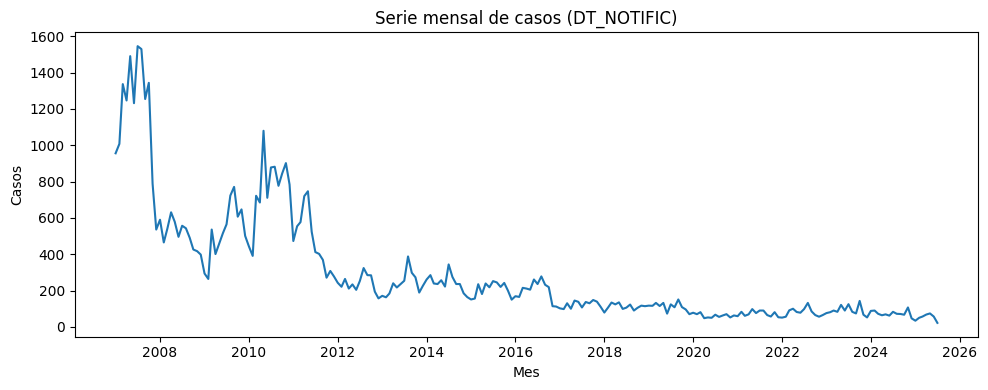

In [5]:
df = df.copy()
df["DT_NOTIFIC"] = pd.to_datetime(df["DT_NOTIFIC"], errors="coerce")
df = df[df["DT_NOTIFIC"].notna()].copy()

df["mes"] = df["DT_NOTIFIC"].dt.to_period("M").dt.to_timestamp()
serie_mes = df.groupby("mes").size().reset_index(name="casos")
display(serie_mes.head())

plt.figure(figsize=(10, 4))
plt.plot(serie_mes["mes"], serie_mes["casos"])
plt.title("Serie mensal de casos (DT_NOTIFIC)")
plt.xlabel("Mes")
plt.ylabel("Casos")
plt.tight_layout()

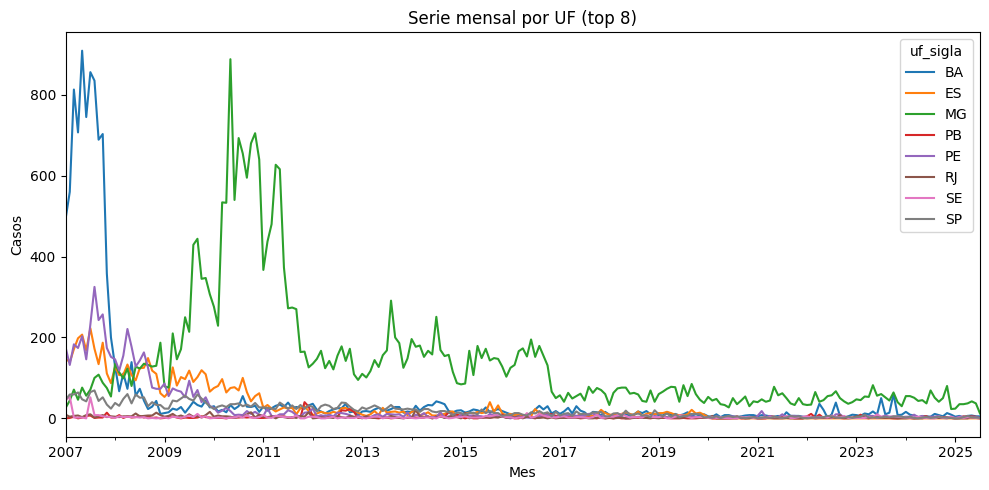

In [6]:
df["uf_sigla"] = df["uf_sigla"].astype("string").str.upper()
serie_mes_uf = df.groupby(["mes", "uf_sigla"]).size().reset_index(name="casos")

top_ufs = (
    serie_mes_uf.groupby("uf_sigla")["casos"].sum()
    .sort_values(ascending=False)
    .head(8)
    .index
    .tolist()
 )

serie_pivot = (
    serie_mes_uf[serie_mes_uf["uf_sigla"].isin(top_ufs)]
    .pivot(index="mes", columns="uf_sigla", values="casos")
    .fillna(0)
    .sort_index()
 )

ax = serie_pivot.plot(figsize=(10, 5))
ax.set_title("Serie mensal por UF (top 8)")
ax.set_xlabel("Mes")
ax.set_ylabel("Casos")
plt.tight_layout()

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

# -- 1. Carregar populacao UFs -------------------------------------------------
pop_ufs_dir = Path("../../data/populacao/ufs")
pop_files = sorted(pop_ufs_dir.glob("pop_ufs_*.parquet"))
if not pop_files:
    raise FileNotFoundError(f"Nenhum parquet encontrado em: {pop_ufs_dir.resolve()}")

pop_ufs_list = []
for file_path in pop_files:
    year = int(file_path.stem.split("_")[-1])
    df_pop = pd.read_parquet(file_path)
    if "ano" not in df_pop.columns:
        df_pop["ano"] = year
    pop_ufs_list.append(df_pop)

pop_ufs = pd.concat(pop_ufs_list, ignore_index=True)

# -- 2. Normalizar tipos e chaves (SEM geobr) ---------------------------------
# Forçamos o 'code_state' e o 'ano' para números inteiros (Int64)
pop_ufs["ano"] = pd.to_numeric(pop_ufs["ano"], errors="coerce").astype("Int64")
pop_ufs["code_state"] = pd.to_numeric(pop_ufs["code_state"], errors="coerce").astype("Int64")

anos_populacao = sorted(pop_ufs["ano"].dropna().astype(int).unique().tolist())
if not anos_populacao:
    raise ValueError("Nenhum ano valido encontrado em pop_ufs.")

# Diagnostico rapido
print(f"Diagnostico pop_ufs: linhas={len(pop_ufs):,} | code_state nulos={pop_ufs['code_state'].isna().mean():.1%}")
if len(anos_populacao) > 5:
    print(f"Anos populacao: {anos_populacao[:5]} ... {anos_populacao[-5:]}")
else:
    print(f"Anos populacao: {anos_populacao}")

# -- 3. Heuristica: ano de populacao mais proximo do ano do caso --------------
def ano_mais_proximo(ano_caso: int, anos_disponiveis: list[int]) -> int:
    return min(anos_disponiveis, key=lambda a: abs(a - ano_caso))

# -- 4. Contar casos por ano e UF ---------------------------------------------
df_ano = df.copy()
df_ano["ano"] = df_ano["DT_NOTIFIC"].dt.year

# Forçamos o 'SG_UF' (que tem os códigos numéricos) e o 'ano' para Int64 também!
df_ano["SG_UF"] = pd.to_numeric(df_ano["SG_UF"], errors="coerce").astype("Int64")
df_ano["ano"] = df_ano["ano"].astype("Int64")

casos_uf = (
    df_ano.groupby(["ano", "SG_UF"])
    .size()
    .reset_index(name="casos")
)
print(f"Diagnostico casos_uf: linhas={len(casos_uf):,} | SG_UF nulos={casos_uf['SG_UF'].isna().mean():.1%}")

# -- 5. Mapear para o ano de populacao mais proximo ---------------------------
casos_uf["ano_pop"] = casos_uf["ano"].apply(
    lambda a: ano_mais_proximo(a, anos_populacao) if pd.notna(a) else pd.NA
)
casos_uf["ano_pop"] = casos_uf["ano_pop"].astype("Int64")

# -- 6. Merge com populacao usando ano_pop e o codigo da UF -------------------
# Adicionamos 'nome_uf' na seleção para trazer o nome completo do estado também
pop_ref = pop_ufs[["ano", "code_state", "populacao", "nome_uf"]].rename(
    columns={"ano": "ano_pop", "code_state": "SG_UF"}
)

inc_uf = casos_uf.merge(pop_ref, on=["ano_pop", "SG_UF"], how="left", indicator=True)

# Dicionário oficial do IBGE para gerar a 'uf_sigla' (2 letras)
mapa_siglas = {
    11: 'RO', 12: 'AC', 13: 'AM', 14: 'RR', 15: 'PA', 16: 'AP', 17: 'TO',
    21: 'MA', 22: 'PI', 23: 'CE', 24: 'RN', 25: 'PB', 26: 'PE', 27: 'AL', 28: 'SE', 29: 'BA',
    31: 'MG', 32: 'ES', 33: 'RJ', 35: 'SP',
    41: 'PR', 42: 'SC', 43: 'RS',
    50: 'MS', 51: 'MT', 52: 'GO', 53: 'DF'
}
# Criamos a nova coluna mapeando os códigos
inc_uf["uf_sigla"] = inc_uf["SG_UF"].map(mapa_siglas).astype("string")

missing_pop = inc_uf["populacao"].isna().mean()
print(f"Diagnostico merge: populacao nula={missing_pop:.1%}")

if missing_pop > 0:
    display(inc_uf[inc_uf["populacao"].isna()].head(10))

inc_uf = inc_uf.drop(columns=["_merge", "ano_pop"])
inc_uf["inc_100k"] = (inc_uf["casos"] / inc_uf["populacao"]) * 100_000

# Reorganizando as colunas para deixar o DataFrame elegante e pronto para o plot
ordem_colunas = ["ano", "SG_UF", "uf_sigla", "nome_uf", "casos", "populacao", "inc_100k"]
inc_uf = inc_uf[ordem_colunas].sort_values(["ano", "inc_100k"], ascending=[True, False]).reset_index(drop=True)

display(inc_uf.head(50))

Diagnostico pop_ufs: linhas=405 | code_state nulos=0.0%
Anos populacao: [2008, 2009, 2011, 2012, 2013] ... [2019, 2020, 2021, 2024, 2025]
Diagnostico casos_uf: linhas=384 | SG_UF nulos=0.0%
Diagnostico merge: populacao nula=0.0%


,ano,SG_UF,uf_sigla,nome_uf,casos,populacao,inc_100k
0,2007,32,ES,Espírito Santo,1879,3453646,54.406271
1,2007,29,BA,Bahia,7870,14502563,54.266270
2,2007,26,PE,Pernambuco,2399,8734196,27.466753
3,2007,28,SE,Sergipe,184,1999374,9.202881
4,2007,31,MG,Minas Gerais,859,19850060,4.327443
5,2007,11,RO,Rondônia,44,1493565,2.945972
6,2007,24,RN,Rio Grande do Norte,79,3106436,2.543107
7,2007,27,AL,Alagoas,68,3127560,2.174219
8,2007,35,SP,São Paulo,602,41011638,1.467876
9,2007,25,PB,Paraíba,42,3742604,1.122213


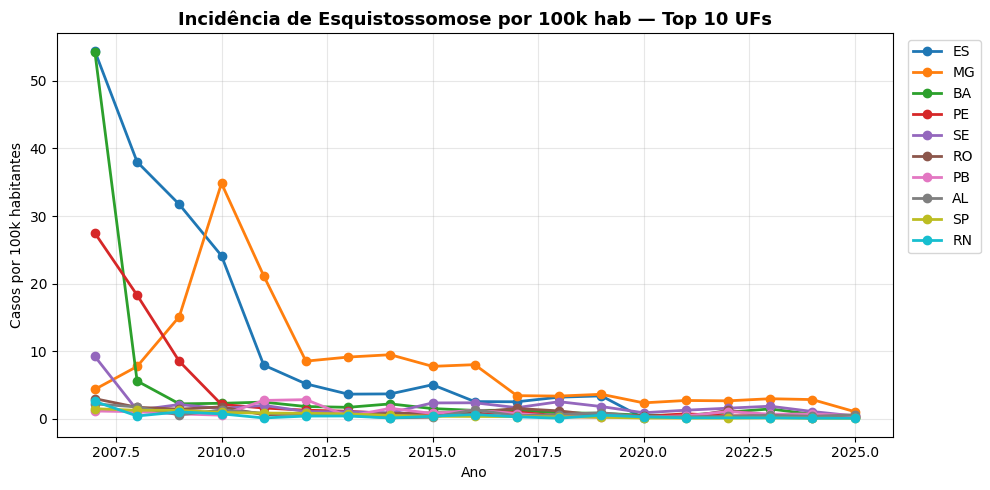

In [8]:
# ── 7. Grafico — Top 10 UFs com maior incidencia media ───────────────────────
top_ufs = (
    inc_uf.groupby("uf_sigla")["inc_100k"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .index.tolist()
)

fig, ax = plt.subplots(figsize=(10, 5))
df_top = inc_uf[inc_uf["uf_sigla"].isin(top_ufs)]
for uf in top_ufs:
    serie = df_top[df_top["uf_sigla"] == uf].sort_values("ano")
    ax.plot(serie["ano"], serie["inc_100k"], marker="o", label=uf, linewidth=2)

ax.set_title("Incidência de Esquistossomose por 100k hab — Top 10 UFs", fontsize=13, fontweight="bold")
ax.set_xlabel("Ano")
ax.set_ylabel("Casos por 100k habitantes")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

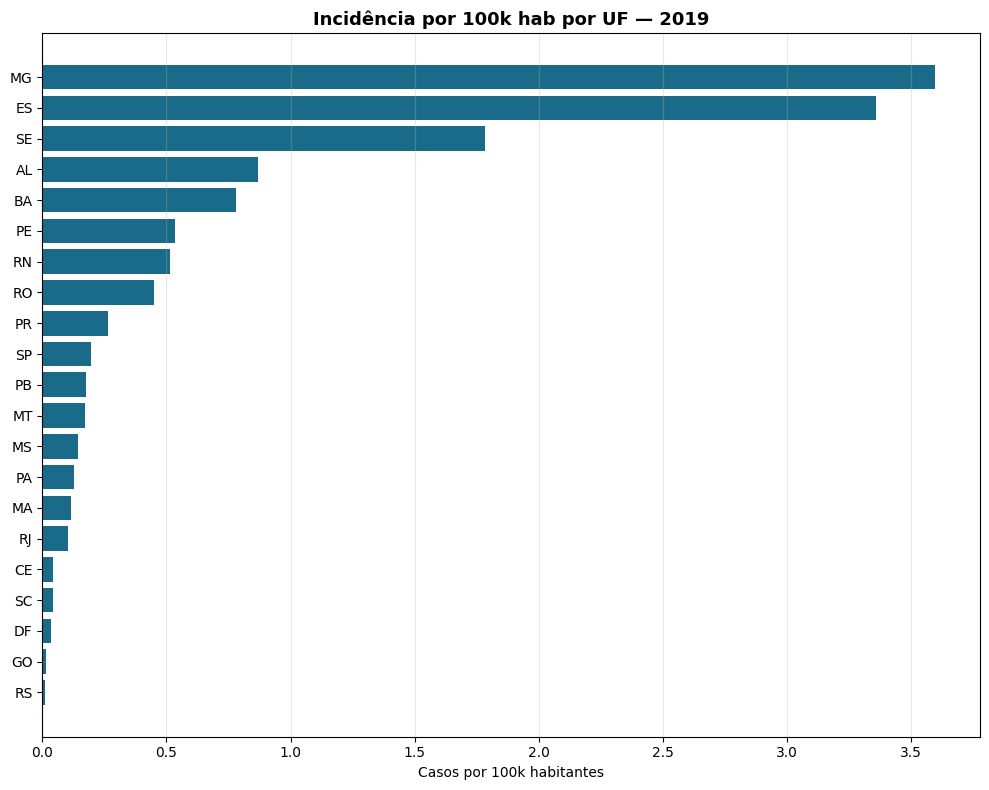

In [9]:
# ── 8. Grafico — Ranking UFs num ano especifico ───────────────────────────────
ANO_VIZ = 2019  # altere aqui

df_rank = inc_uf[inc_uf["ano"] == ANO_VIZ].sort_values("inc_100k", ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(df_rank["uf_sigla"], df_rank["inc_100k"], color="#1a6b8a")
ax.set_title(f"Incidência por 100k hab por UF — {ANO_VIZ}", fontsize=13, fontweight="bold")
ax.set_xlabel("Casos por 100k habitantes")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

essa próxima celula funcionou uma vez mas deu erro em certo momento, talvez seja problema do geobr e geopandas

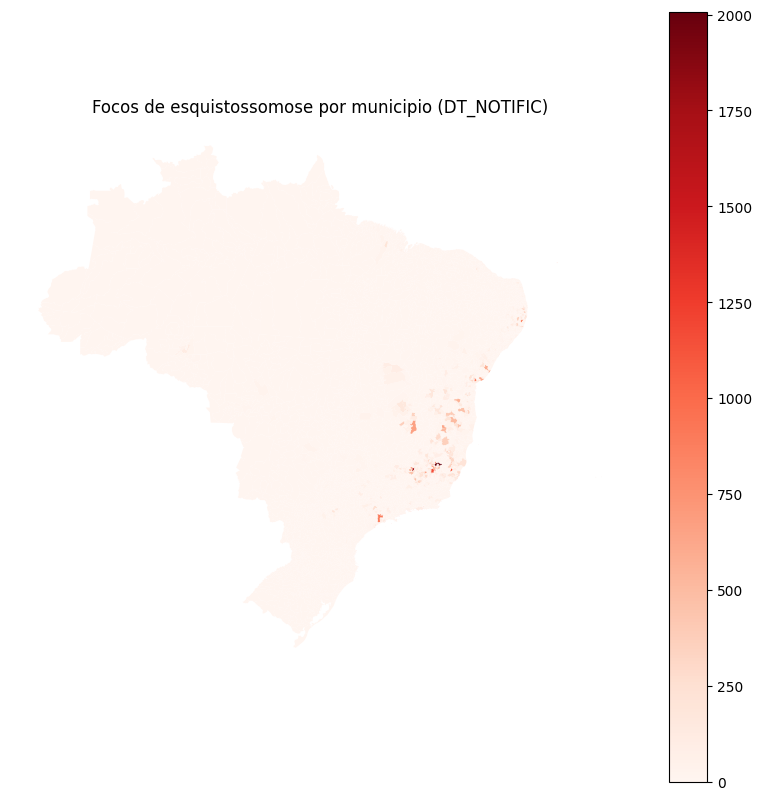

In [10]:
try:
    import geobr
    import geopandas as gpd
except ImportError as exc:
    raise SystemExit("Instale geobr e geopandas para o mapa.") from exc

ag_municipio = df.groupby("ID_MUNICIP").size().reset_index(name="casos")
ag_municipio["ID_MUNICIP"] = ag_municipio["ID_MUNICIP"].astype("string").str.zfill(6)

gdf = geobr.read_municipality(code_muni="all", year=2020)
gdf["code_muni_str"] = gdf["code_muni"].astype("string").str[:6]

gdf_plot = gdf.merge(
    ag_municipio,
    left_on="code_muni_str",
    right_on="ID_MUNICIP",
    how="left",
)

gdf_plot["casos"] = gdf_plot["casos"].fillna(0)

ax = gdf_plot.plot(
    column="casos",
    cmap="Reds",
    linewidth=0.1,
    figsize=(10, 10),
    legend=True,
)
ax.set_title("Focos de esquistossomose por municipio (DT_NOTIFIC)")
ax.set_axis_off()

## Proximo Passo: Observar estados com maior incidencia para identificar focos